<a href="https://colab.research.google.com/github/ayushpaliwal1920/CODSOFT_Quizz/blob/master/05_Handwriiten_Digit_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handwritten Digit Clssification using ANN

it is multiclass classification problem , and we are using MNIST dataset here.

In [73]:
import pandas as pd
import numpy as np

In [74]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [75]:
# MNIST dataset : keras has built_in dataset

(x_train,y_train),(x_test,y_test) = keras.datasets.mnist.load_data()

In [76]:
# shape : it is 3d data , images stored in pixel values
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


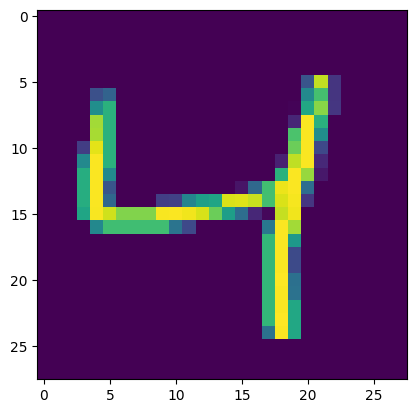

In [77]:
# pixel value to images

import matplotlib.pyplot as plt
plt.imshow(x_train[2])


In [78]:
# Scalling : values should be in range of [0,1]

x_train = x_train/255
x_test = x_test/255


In [79]:
# ANN :

model = Sequential()

# Converting high dimensional arrays into 1D.

model.add(Flatten(input_shape =(28,28))) # converting 28*28 into 1*728

# Creating Hidden Layers   :

model.add(Dense(128,activation='relu'))
model.add(Dense(32,activation='relu'))

# Creating output layer : when we have more than one output we will use "softmax" function :

model.add(Dense(10,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [80]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
# Compile model

# sparse_categorical_crossentropy ,by using this loss function we do not have to One hot encode out labeled data.
model.compile(loss="sparse_categorical_crossentropy",optimizer="Adam")

In [82]:
# Training Model :

history = model.fit(x_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.2802 - val_loss: 0.1572
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1176 - val_loss: 0.1279
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0817 - val_loss: 0.1076
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0615 - val_loss: 0.1091
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0469 - val_loss: 0.0949
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0379 - val_loss: 0.1096
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0298 - val_loss: 0.0973
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0278 - val_loss: 0.0924
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0207 - val_loss: 0.1171
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0190 - val_loss: 0.1259


In [83]:
# prediction

y_prob = model.predict(x_test)

y_pred = y_prob.argmax(axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [84]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,y_pred)*100)

97.41


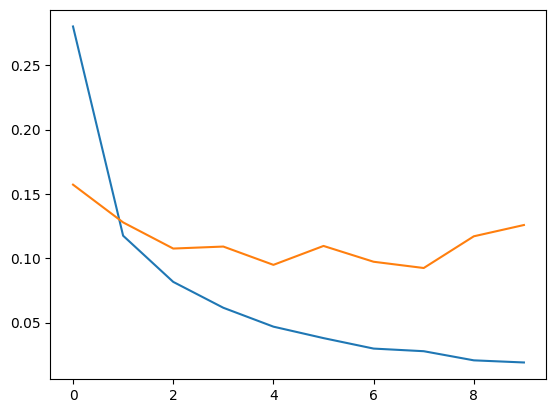

In [85]:
# Plotting :

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

Checking Real and Predicted value :

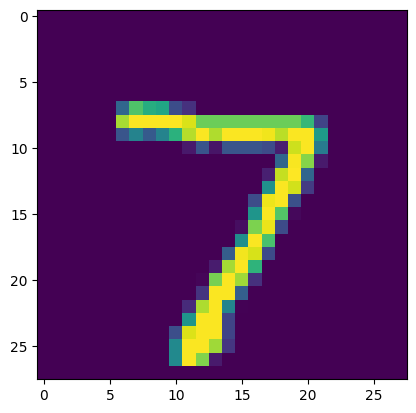

In [88]:
# Real value :
plt.imshow(x_test[0])

In [92]:
# Predicted value :

model.predict(x_test[0].reshape(1,28,28)).argmax(axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([7])